# <img style="float: left; padding: 0px 10px 0px 0px;" src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/84/Escudo_de_la_Pontificia_Universidad_Cat%C3%B3lica_de_Chile.svg/1920px-Escudo_de_la_Pontificia_Universidad_Cat%C3%B3lica_de_Chile.svg.png"  width="80" /> IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Semestre 2021-1**<br>
**Profesora:** Paula Aguirre <br>

## Clases 3 - 4: Tipos y formatos de datos

---

Data Product 3 - Casos totales por región incremental: Archivo con valores separados por coma (csv) que concatena historia de publicaciones de casos totales por parte de MINSAL. El archivo contiene una columna 'Región', seguida por columnas correspondientes a '[fecha]'. Estas últimas columnas, ‘[fecha]’, contienen los 'Casos Confirmados' reportados por el Ministerio de Salud de Chile en cada una de las fechas que se indican en las respectivas columnas. Incluye versión con serie de tiempo. Ver más.


## 1. Módulos de Python

Todos los Notebooks y códigos deberían comenzar con la importación de módulos, o librerías de funciones built-in para distintos usos. Para facilitar la referencia a librerías en el resto del código, se acostumbra asignarles un alias. La sintaxis a usar para importar un módulo es:


``import NOMBRE_MODULO as ALIAS_MODULO``

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## 2. Ubicación de archivos.

Antes de improtar archvios de datos, necesitamos identificar dónde están guardados dentro de nuestro sistema, y en qué directorio estamos trabajando ("working directory").

Algunos comandos importantes:
- `!ls`: lista el contenido del directorio actual command lists all content in the current working directory.
- `%cd 'subdirectorio'`: permite cambiar la ubicación actual a 'subdirectorio'
- `cd ..`: permite navegar hacia atrás al directorio superior del actual
- `!pwd`: entrega la ruta del directorio actual
      

In [2]:
pwd

'/Volumes/GoogleDrive/Mi unidad/Cursos/IMT2200_IntroCienciaDatos/imt2200_clases_local/clase3'

In [3]:
!ls

CasosTotalesCumulativo.csv Icon?
IMT2200_clase3.ipynb       ~$IMT2200_clase3.pptx
IMT2200_clase3.pdf


In [4]:
%cd ..

/Volumes/GoogleDrive/Mi unidad/Cursos/IMT2200_IntroCienciaDatos/imt2200_clases_local


In [6]:
!ls
%cd clase3
!ls

CasosTotalesCumulativo.csv Icon?
IMT2200_clase3.ipynb       ~$IMT2200_clase3.pptx
IMT2200_clase3.pdf
[Errno 2] No such file or directory: 'clase3'
/Volumes/GoogleDrive/Mi unidad/Cursos/IMT2200_IntroCienciaDatos/imt2200_clases_local/clase3
CasosTotalesCumulativo.csv Icon?
IMT2200_clase3.ipynb       ~$IMT2200_clase3.pptx
IMT2200_clase3.pdf


In [8]:
data_file='CasosTotalesCumulativo.csv'

## 2. Importación de datos.

Veremos primero cómo importar, inspeccionar y graficar datos estructurados.

### 2.1 `numpy`: np.loadtxt() y np.genfromtxt()

Numpy provee funciones para leer archivos de texto estructurado directamente como arreglos (`np.ndarray`). En primer lugar la función `np.loadtxt()`, permite cargar archivos cuyo contenido es solamente numérico. Sin embargo, generalmente trabajaremos con datasets que tienen distintos tipos de datos en distintas columnas; por ejemplo, strings y floats. En este caso, es necesario utilizar la función `np.genfromtxt()`, que puede manejar estas estructuras. Si pasamos como argumento `dtype=None`, la función infiere el tipo de datos de cada columna.

La documentación de ambas funciones se encuentra en: <br>
- https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html
- https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html


In [9]:
# Importar archivo: data
data = np.loadtxt(data_file, delimiter=',', dtype='str')#skiprows=1

# Explorar la data
print(data[0])
print(data.shape)
print(data)

['Region' '2020-03-03' '2020-03-04' '2020-03-05' '2020-03-06' '2020-03-07'
 '2020-03-08' '2020-03-09' '2020-03-10' '2020-03-11' '2020-03-12'
 '2020-03-13' '2020-03-14' '2020-03-15' '2020-03-16' '2020-03-17'
 '2020-03-18' '2020-03-19' '2020-03-20' '2020-03-21' '2020-03-22'
 '2020-03-23' '2020-03-24' '2020-03-25' '2020-03-26' '2020-03-27'
 '2020-03-28' '2020-03-29' '2020-03-30' '2020-03-31' '2020-04-01'
 '2020-04-02' '2020-04-03' '2020-04-04' '2020-04-05' '2020-04-06'
 '2020-04-07' '2020-04-08' '2020-04-09' '2020-04-10' '2020-04-11'
 '2020-04-12' '2020-04-13' '2020-04-14' '2020-04-15' '2020-04-16'
 '2020-04-17' '2020-04-18' '2020-04-19' '2020-04-20' '2020-04-21'
 '2020-04-22' '2020-04-23' '2020-04-24' '2020-04-25' '2020-04-26'
 '2020-04-27' '2020-04-28' '2020-04-29' '2020-04-30' '2020-05-01'
 '2020-05-02' '2020-05-03' '2020-05-04' '2020-05-05' '2020-05-06'
 '2020-05-07' '2020-05-08' '2020-05-09' '2020-05-10' '2020-05-11'
 '2020-05-12' '2020-05-13' '2020-05-14' '2020-05-15' '2020-05-16'
 

In [ ]:
# Importar data como floats y saltar la primera fila: data_float
data = np.genfromtxt(data_file, delimiter=',', dtype=None,skip_header=1)

print(data[0])
print(data.shape)


#numpy se las puede arreglar con datos mezclados pero es mejor panda

En general, `numpy` se las puede arreglar con conjuntos de datos con tipos mezclados, pero la librería natural para trabajar con datos estructurados es `pandas`.

### 2.2 `pandas`: read_csv y DataFrames

La función `pd.read_csv()` permite leer un archivo de texto en formato CSV (comma separated value) y generar un DataFrame.
El delimitador por defecto es la coma (,), pero también pueden leerse datasets con otros tipos de separación, especificando el parámetro `delimiter`.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html


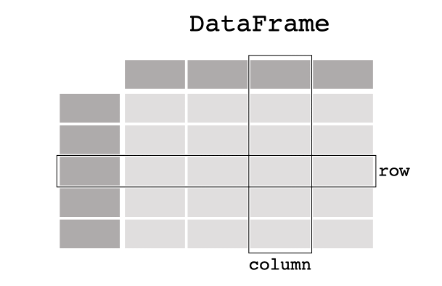

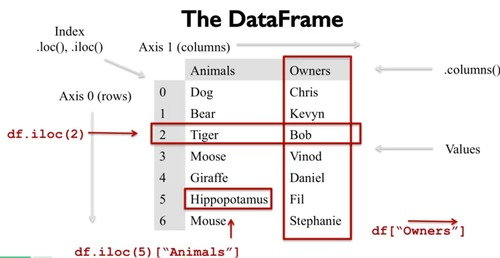


#### Leer e inspeccionar un DataFrame.


In [ ]:
dat=pd.read_csv('CasosTotalesCumulativo.csv', delimiter=',')
dat

In [ ]:
dat

In [ ]:
dat.columns

In [ ]:
dat.head()

#### Índices y acceso a información de celdas.

In [ ]:
dat.iloc[1:3]

In [ ]:
dat['Region']

In [ ]:
dat_maule=dat[dat['Region']=='Maule']
dat_maule

#### Operaciones con columnas.

Cada columna de un DataFrame es una Serie, que corresponde a un arreglo 1-D con una etiqueta. Por lo tanto, en el caso de columnas con datos numéricos, podemos aplicar todas las operaciones matemáticas disponibles en `numpy`:

https://numpy.org/doc/stable/reference/routines.math.html

También podemos realizar operaciones entre 2 o más columnas, o entre columnas y escalares.


### 2.3 `geopandas`: read_file y GeoDataFrames

Geopandas funciona de manera muy similar a pandas, y tiene implemenada la función `read_file`para leer datos vectoriales en prácticamente cualquier formato.

https://geopandas.org/docs/reference/api/geopandas.read_file.html

Veremos a continuación como leer, inspeccionar y graficar un GeoDataFrame.


In [2]:
gdf=gpd.read_file('R13/COMUNA_C17.shp')

In [3]:
gdf.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-70.61889 -33.73808, -70.61811 -33.7..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-70.63192 -33.64634, -70.63207 -33.6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-70.78914 -33.36153, -70.78824 -33.3..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-70.59630 -32.95138, -70.59673 -32.9..."


In [4]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   REGION      52 non-null     object  
 1   NOM_REGION  52 non-null     object  
 2   PROVINCIA   52 non-null     object  
 3   NOM_PROVIN  52 non-null     object  
 4   COMUNA      52 non-null     object  
 5   NOM_COMUNA  52 non-null     object  
 6   SHAPE_Leng  52 non-null     float64 
 7   SHAPE_Area  52 non-null     float64 
 8   geometry    52 non-null     geometry
dtypes: float64(2), geometry(1), object(6)
memory usage: 3.8+ KB


In [5]:
gdf.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - SIRGAS 2000 by country
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

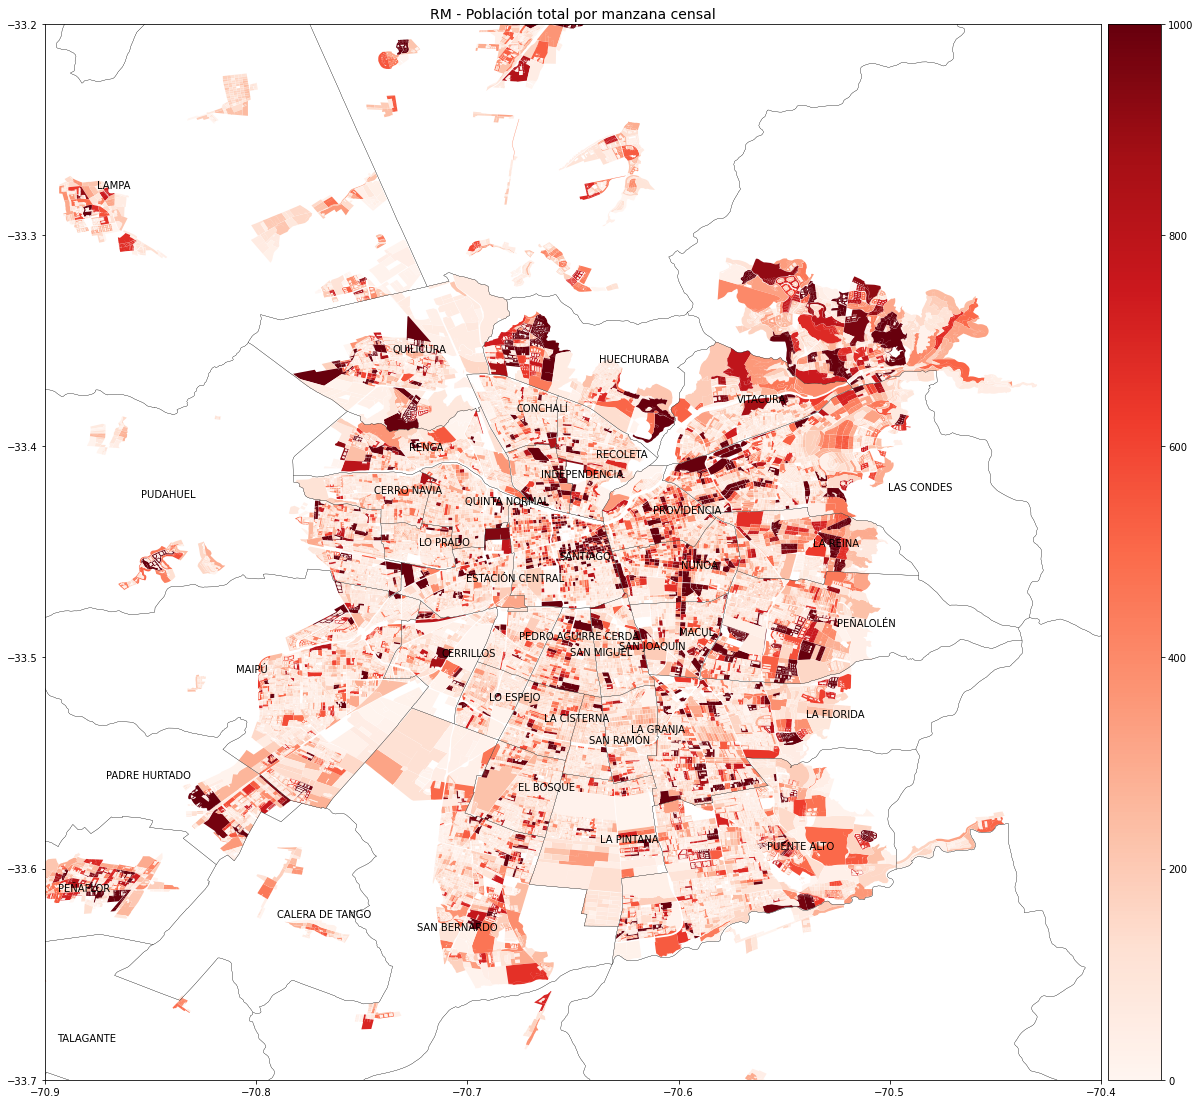

In [6]:
#recordar de la Tarea 0
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors

#Crear figura y ejes
fig=plt.figure(figsize=(20,20))
ax=fig.add_subplot(111)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

#Leer datos censales
manz=gpd.read_file('R13/MANZANA_IND_C17.shp')
com=gpd.read_file('R13/COMUNA_C17.shp')


Z=manz['TOTAL_PERS']
manz.plot(ax=ax,column='TOTAL_PERS',cmap='Reds',legend=True, vmin=0,vmax=1000,cax=cax)

com.boundary.plot(ax=ax,lw=0.2,color='k')

xlim=[-70.9,-70.4]
ylim=[-33.7,-33.2]
for x, y, label in zip(com.geometry.centroid.x, com.geometry.centroid.y, com.NOM_COMUNA):
    if xlim[0]<x<xlim[1] and ylim[0]<y<ylim[1]:
        ax.text(x, y, label, fontsize = 10)
        
ax.set_xlim(xlim)
ax.set_ylim(ylim);

ax.set_title('RM - Población total por manzana censal',fontsize=14)

## Reemplace 'XXX' por su apellido en el nombre del archivo de salida 
fig.savefig('PoblacionRM_C2017_XXXX.jpg')